 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.feature_selection import mutual_info_classif

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

2. LOAD DATASET

In [4]:
data_path = r"C:\Users\SREEKUTTY\.cache\kagglehub\datasets\selonamaris\large-industrial-pump-maintenance-dataset\versions\1\Large_Industrial_Pump_Maintenance_Dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")


Dataset loaded successfully!


3. DATASET SHAPE

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset shape:", df.shape)


Number of rows: 20000
Number of columns: 8

Dataset shape: (20000, 8)


 4. COLUMN INFORMATION

In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Column names:
['Pump_ID', 'Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours', 'Maintenance_Flag']

Data types:
Pump_ID                int64
Temperature          float64
Vibration            float64
Pressure             float64
Flow_Rate            float64
RPM                  float64
Operational_Hours    float64
Maintenance_Flag       int64
dtype: object

First 5 rows:


,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
0,2,127.5084,2.3694,136.0210,6.5015,1444.1919,3966.7937,1
1,4,88.9752,4.5411,147.5170,7.0015,1004.8025,3673.2889,0
2,3,61.8323,2.5421,220.8586,8.8244,2597.6627,5489.0610,1
3,3,106.2503,2.8345,145.8171,16.2835,2280.9263,3134.7830,0
4,2,84.8159,3.1197,235.4762,8.3852,2594.1317,761.5332,1



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pump_ID            20000 non-null  int64  
 1   Temperature        20000 non-null  float64
 2   Vibration          20000 non-null  float64
 3   Pressure           20000 non-null  float64
 4   Flow_Rate          20000 non-null  float64
 5   RPM                20000 non-null  float64
 6   Operational_Hours  20000 non-null  float64
 7   Maintenance_Flag   20000 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 1.2 MB


5. MISSING VALUES

In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Pump_ID              0
Temperature          0
Vibration            0
Pressure             0
Flow_Rate            0
RPM                  0
Operational_Hours    0
Maintenance_Flag     0
dtype: int64

Total missing values: 0


6. DUPLICATE CHECK

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


7. DESCRIPTIVE STATISTICS

In [9]:
print("Descriptive statistics:")
display(df.describe())

Descriptive statistics:


,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
count,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000,20000.0000
mean,3.0036,100.3713,2.5279,200.3816,10.2481,2005.6172,5030.4810,0.4984
std,1.4104,28.8514,1.4165,57.8231,5.6463,576.5067,2867.8045,0.5000
min,1.0000,50.0011,0.1004,100.0071,0.5005,1000.0418,100.2139,0.0000
25%,2.0000,75.4032,1.3002,149.8585,5.3549,1506.0730,2531.5523,0.0000
50%,3.0000,100.7529,2.5177,200.5139,10.2846,2009.7337,5032.7608,0.0000
75%,4.0000,125.4226,3.7555,250.2717,15.1493,2503.3397,7504.4638,1.0000
max,5.0000,149.9953,4.9998,299.9808,19.9994,2999.9152,9998.7690,1.0000


8. CLASS BALANCE

Class counts:
Maintenance_Flag
0    10032
1     9968
Name: count, dtype: int64

Class percentages:
Maintenance_Flag
0   50.1600
1   49.8400
Name: proportion, dtype: float64


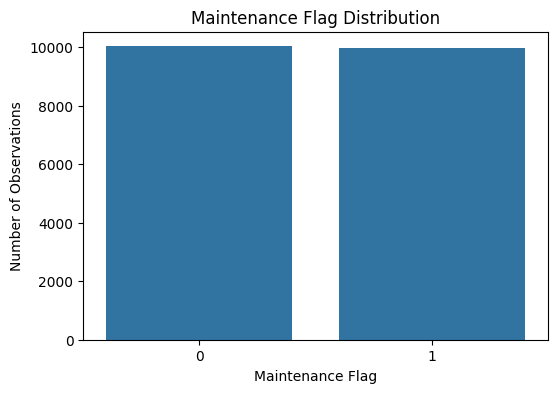

In [10]:
target = "Maintenance_Flag"

class_counts = df[target].value_counts()
class_percentages = df[target].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=target)

plt.title("Maintenance Flag Distribution")
plt.xlabel("Maintenance Flag")
plt.ylabel("Number of Observations")

plt.show()



 9. FEATURE DISTRIBUTIONS

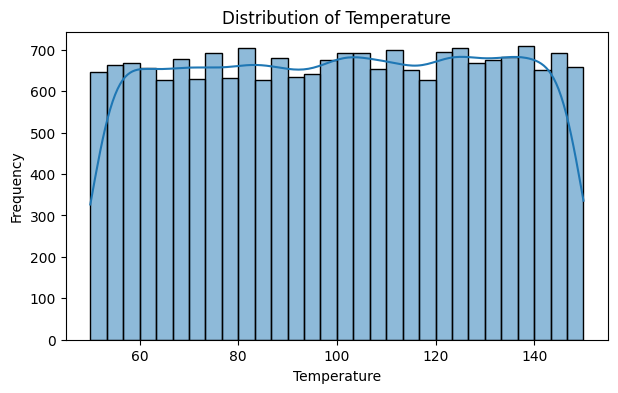

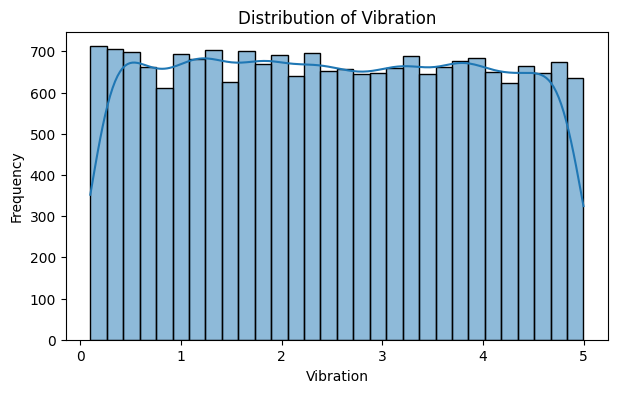

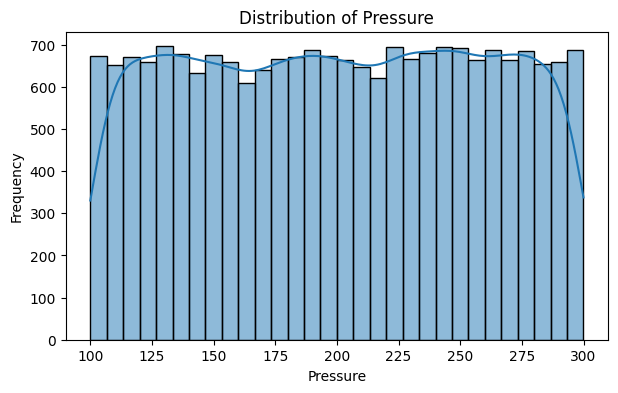

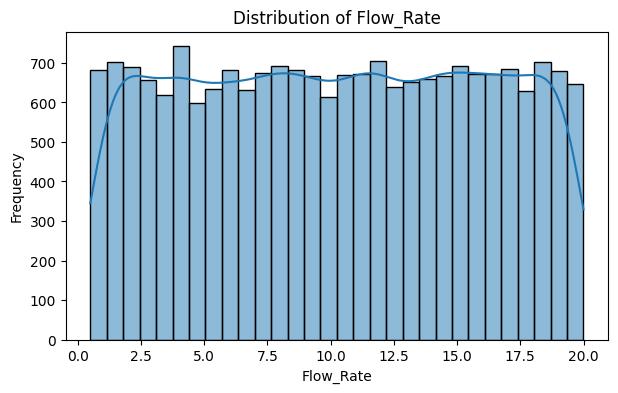

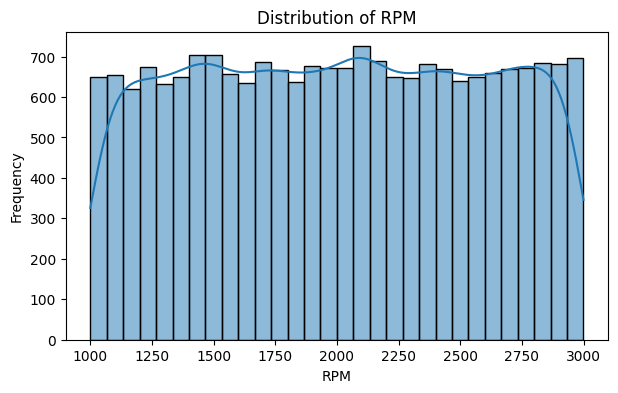

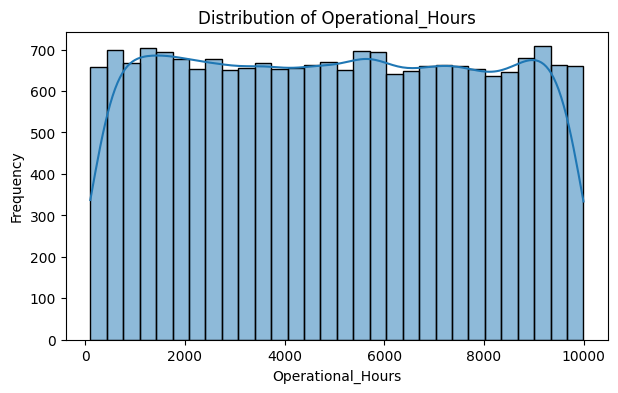

In [11]:
features = [
    "Temperature",
    "Vibration",
    "Pressure",
    "Flow_Rate",
    "RPM",
    "Operational_Hours"
]

for feature in features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()


 10. BOXPLOTS

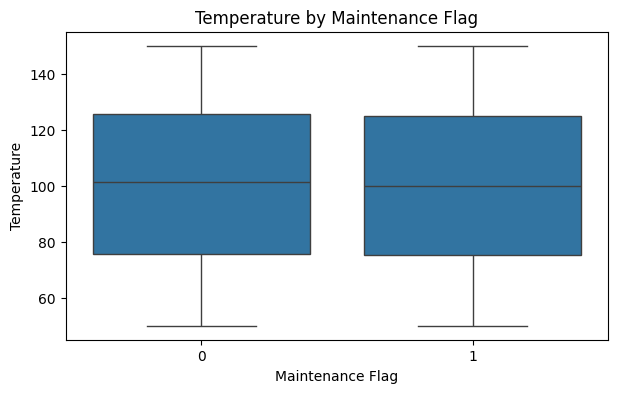

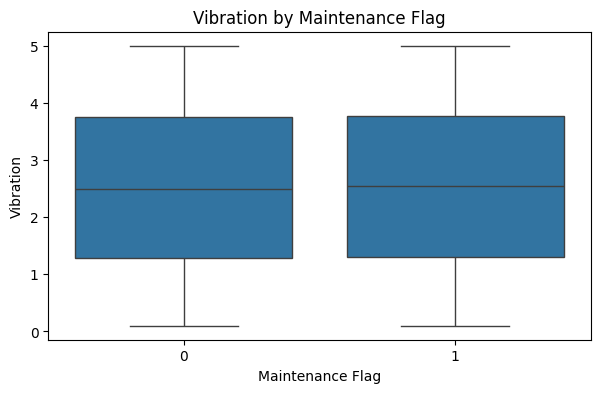

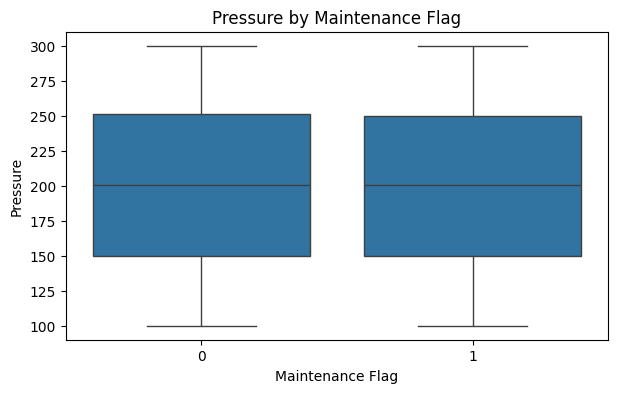

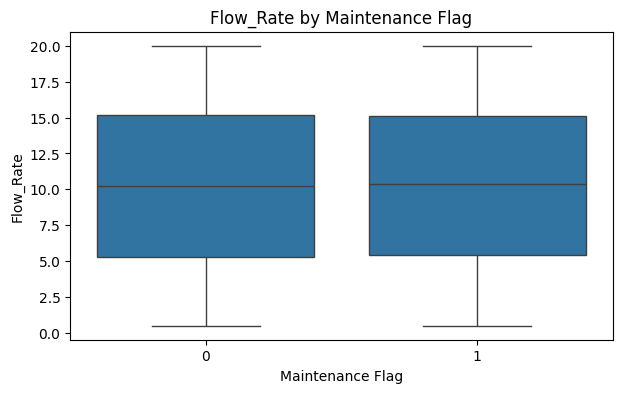

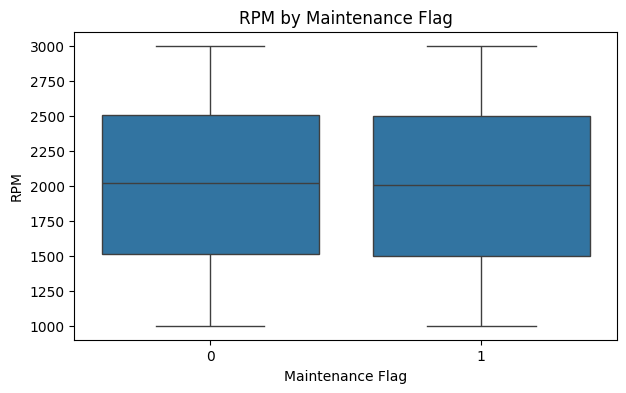

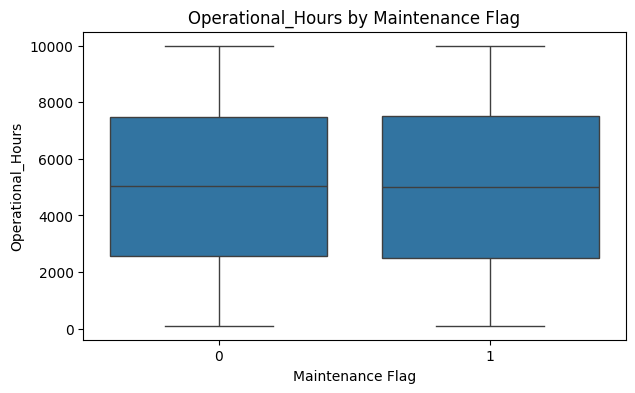

In [12]:
for feature in features:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x=target,
        y=feature
    )

    plt.title(f"{feature} by Maintenance Flag")
    plt.xlabel("Maintenance Flag")
    plt.ylabel(feature)

    plt.show()

 11. CLASS-WISE ANALYSIS

In [13]:
class_means = df.groupby(target)[features].mean()

print("Mean values by Maintenance Flag:")
display(class_means)


print("\nDetailed class-wise statistics:")

for feature in features:

    print(f"\n{'='*60}")
    print(feature)
    print(f"{'='*60}")

    print(
        df.groupby(target)[feature]
        .agg(["mean", "std", "min", "max"])
    )

Mean values by Maintenance Flag:


,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours
Maintenance_Flag,,,,,,
0,100.7468,2.5172,200.6792,10.1993,2010.5388,5039.3378
1,99.9935,2.5386,200.0821,10.2972,2000.6640,5021.5674



Detailed class-wise statistics:

Temperature
                     mean     std     min      max
Maintenance_Flag                                  
0                100.7468 28.8443 50.0034 149.9928
1                 99.9935 28.8550 50.0011 149.9953

Vibration
                   mean    std    min    max
Maintenance_Flag                            
0                2.5172 1.4170 0.1004 4.9991
1                2.5386 1.4159 0.1013 4.9998

Pressure
                     mean     std      min      max
Maintenance_Flag                                   
0                200.6792 57.7577 100.0991 299.9808
1                200.0821 57.8902 100.0071 299.9734

Flow_Rate
                    mean    std    min     max
Maintenance_Flag                              
0                10.1993 5.6537 0.5006 19.9994
1                10.2972 5.6386 0.5005 19.9988

RPM
                      mean      std       min       max
Maintenance_Flag                                       
0                2010.538

12. CORRELATION ANALYSIS

Correlation matrix:


,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
Temperature,1.0000,-0.0038,0.0103,-0.0070,-0.0027,-0.0057,-0.0131
Vibration,-0.0038,1.0000,-0.0007,-0.0108,0.0140,0.0064,0.0076
Pressure,0.0103,-0.0007,1.0000,0.0118,0.0130,0.0043,-0.0052
Flow_Rate,-0.0070,-0.0108,0.0118,1.0000,0.0018,-0.0043,0.0087
RPM,-0.0027,0.0140,0.0130,0.0018,1.0000,0.0081,-0.0086
Operational_Hours,-0.0057,0.0064,0.0043,-0.0043,0.0081,1.0000,-0.0031
Maintenance_Flag,-0.0131,0.0076,-0.0052,0.0087,-0.0086,-0.0031,1.0000


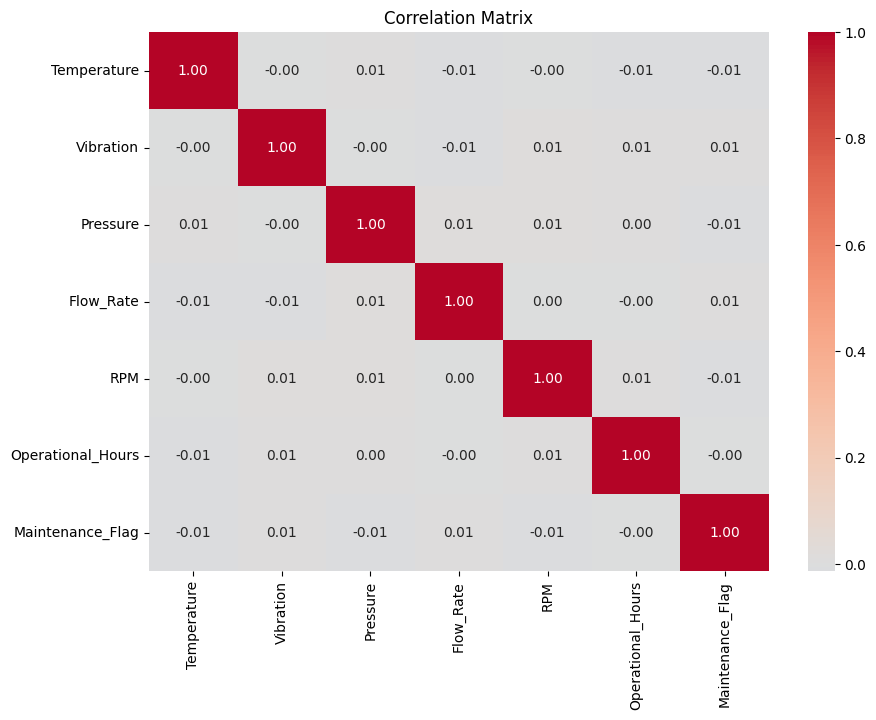

In [14]:
correlation_matrix = df[
    features + [target]
].corr()

print("Correlation matrix:")
display(correlation_matrix)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()


13. MUTUAL INFORMATION

Mutual Information scores:


,Feature,Mutual Information
0,Temperature,0.0014
5,Operational_Hours,0.0006
2,Pressure,0.0003
1,Vibration,0.0000
3,Flow_Rate,0.0000
4,RPM,0.0000


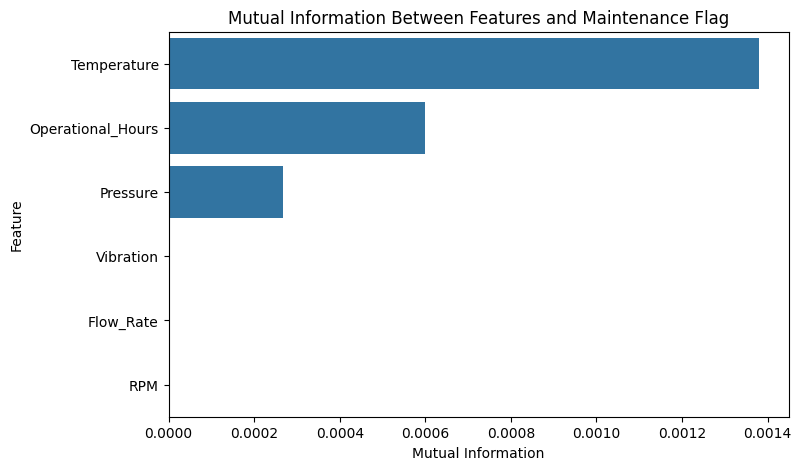

In [15]:
X_mi = df[features]
y_mi = df[target]

mi_scores = mutual_info_classif(
    X_mi,
    y_mi,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": features,
    "Mutual Information": mi_scores
})

mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
)

print("Mutual Information scores:")
display(mi_df)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=mi_df,
    x="Mutual Information",
    y="Feature"
)

plt.title("Mutual Information Between Features and Maintenance Flag")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.show()



14. PUMP_ID INVESTIGATION

Pump ID counts:
Pump_ID
1    3911
2    4129
3    3931
4    4036
5    3993
Name: count, dtype: int64

Maintenance Flag percentage by Pump ID:


Maintenance_Flag,0,1
Pump_ID,,
1,49.7571,50.2429
2,50.1332,49.8668
3,50.0890,49.9110
4,49.4301,50.5699
5,51.3899,48.6101


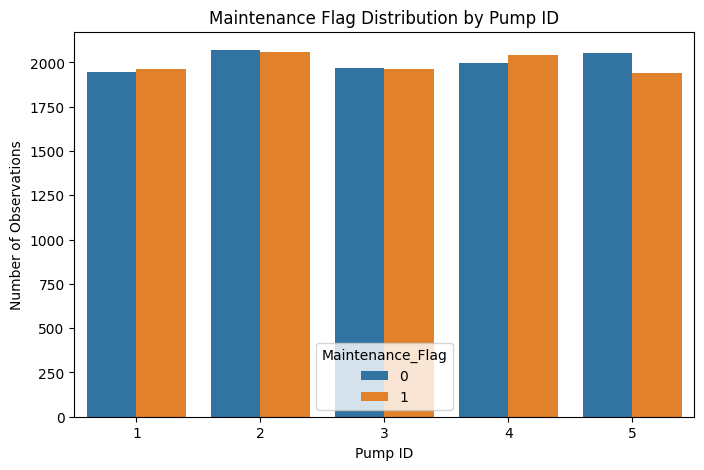

In [16]:
print("Pump ID counts:")
print(df["Pump_ID"].value_counts().sort_index())


pump_target = pd.crosstab(
    df["Pump_ID"],
    df[target],
    normalize="index"
) * 100

print("\nMaintenance Flag percentage by Pump ID:")
display(pump_target)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pump_ID",
    hue=target
)

plt.title("Maintenance Flag Distribution by Pump ID")
plt.xlabel("Pump ID")
plt.ylabel("Number of Observations")

plt.show()



15. OUTLIER ANALYSIS — IQR METHOD

In [17]:
outlier_results = []

for feature in features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (
            len(outliers) / len(df) * 100
        )
    })


outlier_df = pd.DataFrame(outlier_results)

print("IQR-based outlier analysis:")
display(outlier_df)



IQR-based outlier analysis:


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Temperature,75.4032,125.4226,50.0193,0.3742,200.4516,0,0.0000
1,Vibration,1.3002,3.7555,2.4553,-2.3828,7.4385,0,0.0000
2,Pressure,149.8585,250.2717,100.4131,-0.7611,400.8913,0,0.0000
3,Flow_Rate,5.3549,15.1493,9.7944,-9.3367,29.8410,0,0.0000
4,RPM,1506.0730,2503.3397,997.2667,10.1730,3999.2398,0,0.0000
5,Operational_Hours,2531.5523,7504.4638,4972.9116,-4927.8151,14963.8312,0,0.0000


16. DATA LEAKAGE CHECK

In [18]:

print("Features used for prediction:")

print(features)

print("\nTarget:")
print(target)

print("\nTarget included in features?")
print(target in features)

print("\nPump_ID included in features?")
print("Pump_ID" in features)


Features used for prediction:
['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours']

Target:
Maintenance_Flag

Target included in features?
False

Pump_ID included in features?
False


FINAL FEATURE/TARGET DEFINITION

In [19]:
X = df[features]
y = df[target]

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)

print("\nFinal features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


Final X shape: (20000, 6)
Final y shape: (20000,)

Final features:
['Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours']

Target:
Maintenance_Flag
